
Performance Comparison Table

 Array Size  Binary Time (µs)  Binary Comparisons  Interpolation Time (µs)  Interpolation Comparisons
       1000              10.7                   9                      5.3                          1
       5000              11.9                  12                      8.0                          1
      10000               5.5                  13                      3.9                          1
      50000              21.0                  15                      8.8                          1
     100000              19.6                  16                      8.3                          1

Complexity Analysis
--------------------------------------------------
Binary Search:
 Best Case   : O(1)
 Average Case: O(log n)
 Worst Case  : O(log n)
 Space       : O(1)

Interpolation Search:
 Best Case   : O(1)
 Average Case: O(log log n)
 Worst Case  : O(n)
 Space       : O(1)


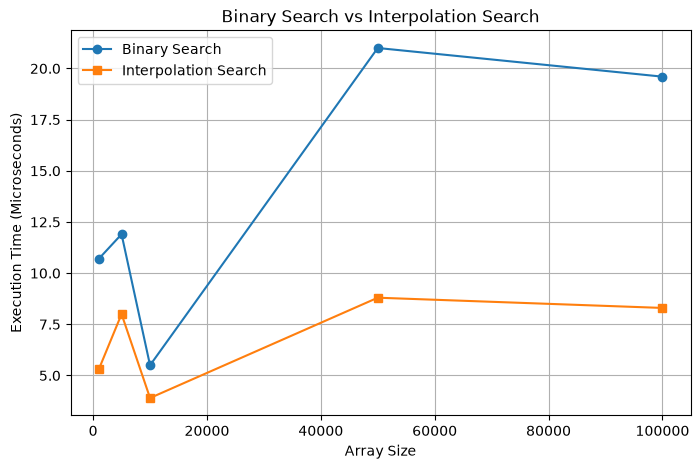

In [1]:
import time
import random
import pandas as pd
import matplotlib.pyplot as plt

def binary_search(arr, key):
    low = 0
    high = len(arr) - 1
    comparisons = 0

    while low <= high:
        mid = (low + high) // 2
        comparisons += 1

        if arr[mid] == key:
            return mid, comparisons
        elif arr[mid] < key:
            low = mid + 1
        else:
            high = mid - 1

    return -1, comparisons

def interpolation_search(arr, key):
    low = 0
    high = len(arr) - 1
    comparisons = 0

    while low <= high and key >= arr[low] and key <= arr[high]:

        if low == high:
            comparisons += 1
            if arr[low] == key:
                return low, comparisons
            return -1, comparisons

        pos = low + int(
            ((high - low) / (arr[high] - arr[low]))
            * (key - arr[low])
        )

        comparisons += 1

        if arr[pos] == key:
            return pos, comparisons

        if arr[pos] < key:
            low = pos + 1
        else:
            high = pos - 1

    return -1, comparisons


sizes = [1000, 5000, 10000, 50000, 100000]

results = []

binary_times = []
interpolation_times = []

for size in sizes:

    # Uniformly distributed sorted array
    arr = list(range(size))

    # Same key for both searches
    key = arr[size // 2]

    # Binary Search
    start = time.perf_counter()
    _, b_comp = binary_search(arr, key)
    end = time.perf_counter()

    b_time = (end - start) * 1e6  # microseconds

    # Interpolation Search
    start = time.perf_counter()
    _, i_comp = interpolation_search(arr, key)
    end = time.perf_counter()

    i_time = (end - start) * 1e6  # microseconds

    binary_times.append(b_time)
    interpolation_times.append(i_time)

    results.append([
        size,
        round(b_time, 3),
        b_comp,
        round(i_time, 3),
        i_comp
    ])

# Result Table

df = pd.DataFrame(
    results,
    columns=[
        "Array Size",
        "Binary Time (µs)",
        "Binary Comparisons",
        "Interpolation Time (µs)",
        "Interpolation Comparisons"
    ]
)

print("\nPerformance Comparison Table\n")
print(df.to_string(index=False))

# Complexity Information
print("\nComplexity Analysis")
print("-" * 50)
print("Binary Search:")
print(" Best Case   : O(1)")
print(" Average Case: O(log n)")
print(" Worst Case  : O(log n)")
print(" Space       : O(1)")

print("\nInterpolation Search:")
print(" Best Case   : O(1)")
print(" Average Case: O(log log n)")
print(" Worst Case  : O(n)")
print(" Space       : O(1)")

# Graph
plt.figure(figsize=(8, 5))

plt.plot(
    sizes,
    binary_times,
    marker='o',
    label='Binary Search'
)

plt.plot(
    sizes,
    interpolation_times,
    marker='s',
    label='Interpolation Search'
)

plt.xlabel("Array Size")
plt.ylabel("Execution Time (Microseconds)")
plt.title("Binary Search vs Interpolation Search")
plt.legend()
plt.grid(True)

plt.show()